# Taller: Construcción e implementación de modelos Bagging, Random Forest y XGBoost

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de Bagging, Random Forest y XGBoost. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este taller se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
#librerias
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [3]:
# Importación de librerías
%matplotlib inline
import pandas as pd

# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,0,0,0,1,0,0,0
11,13995,2014,39972,0,0,0,0,1,0,0
167,17941,2016,18989,0,0,0,0,0,1,0
225,12493,2014,51330,0,0,0,1,0,0,0
270,7994,2007,116065,0,1,0,0,0,0,0


In [8]:
# Separación de variables predictoras (X) y variable de interés (y)
y = (data['Price'] > data['Price'].median()).astype(int)
X = data.drop(['Price'], axis=1)
y.value_counts(normalize=True)

0    0.501572
1    0.498428
Name: Price, dtype: float64

In [9]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Random forest con librería

En la celda 1, usando la librería sklearn entrenen un modelo de Randon Forest para clasificación  y comenten sobre el desempeño del modelo.

In [10]:
# Celda 1
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

baseline_clf = RandomForestClassifier(random_state=42, n_jobs=-1)
baseline_clf.fit(X_train, y_train)
train_accuracy = accuracy_score(y_train, baseline_clf.predict(X_train))
test_accuracy = accuracy_score(y_test, baseline_clf.predict(X_test))
cv_scores = cross_val_score(baseline_clf, X_train, y_train, cv=5, scoring='accuracy')
print(f'Exactitud promedio CV (5 folds): {cv_scores.mean():.3f}')
print(f'Exactitud entrenamiento: {train_accuracy:.3f}')
print(f'Exactitud prueba: {test_accuracy:.3f}')

Exactitud promedio CV (5 folds): 0.809
Exactitud entrenamiento: 0.998
Exactitud prueba: 0.811


### Punto 2 - Calibración de parámetros Random forest

En la celda 2, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para clasificación, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

Mejor n_estimators según CV: 50
Mejor max_features según CV: 8
Mejor max_depth según CV: 5


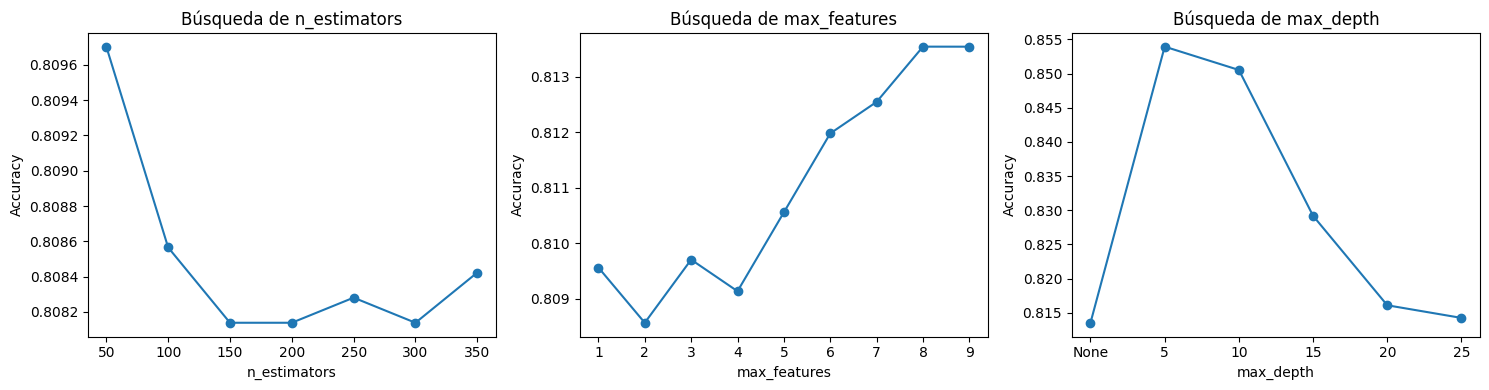

In [11]:
# Celda 2
from sklearn.model_selection import cross_val_score
# Calibración individual de hiperparámetros usando validación cruzada
estimator_range = range(50, 351, 50)
estimator_scores = []
for n_estimators in estimator_range:
    clf = RandomForestClassifier(n_estimators=n_estimators, random_state=42, n_jobs=-1)
    estimator_scores.append(cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy').mean())
best_n_estimators = list(estimator_range)[int(np.argmax(estimator_scores))]

feature_range = range(1, X_train.shape[1] + 1)
feature_scores = []
for max_features in feature_range:
    clf = RandomForestClassifier(n_estimators=best_n_estimators, max_features=max_features, random_state=42, n_jobs=-1)
    feature_scores.append(cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy').mean())
best_max_features = list(feature_range)[int(np.argmax(feature_scores))]

depth_options = [None, 5, 10, 15, 20, 25]
depth_scores = []
for max_depth in depth_options:
    clf = RandomForestClassifier(n_estimators=best_n_estimators, max_features=best_max_features, max_depth=max_depth, random_state=42, n_jobs=-1)
    depth_scores.append(cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy').mean())
best_max_depth = depth_options[int(np.argmax(depth_scores))]

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(list(estimator_range), estimator_scores, marker='o')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.title('Búsqueda de n_estimators')

plt.subplot(1, 3, 2)
plt.plot(list(feature_range), feature_scores, marker='o')
plt.xlabel('max_features')
plt.ylabel('Accuracy')
plt.title('Búsqueda de max_features')

plt.subplot(1, 3, 3)
plt.plot([str(d) for d in depth_options], depth_scores, marker='o')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Búsqueda de max_depth')
plt.tight_layout()

print(f'Mejor n_estimators según CV: {best_n_estimators}')
print(f'Mejor max_features según CV: {best_max_features}')
print(f'Mejor max_depth según CV: {best_max_depth}')


In [ ]:

best_params = {
    'n_estimators': best_n_estimators,
    'max_features': best_max_features,
    'max_depth': best_max_depth,
    'random_state': 42,
    'n_jobs': -1
}
tuned_clf = RandomForestClassifier(**best_params)
tuned_clf.fit(X_train, y_train)
train_accuracy_tuned = accuracy_score(y_train, tuned_clf.predict(X_train))
test_accuracy_tuned = accuracy_score(y_test, tuned_clf.predict(X_test))
cv_scores_tuned = cross_val_score(tuned_clf, X_train, y_train, cv=5, scoring='accuracy')
print('Mejores hiperparámetros encontrados:', best_params)
print(f'Exactitud promedio CV (5 folds): {cv_scores_tuned.mean():.3f}')
print(f'Exactitud entrenamiento: {train_accuracy_tuned:.3f}')
print(f'Exactitud prueba: {test_accuracy_tuned:.3f}')


In [ ]:
feature_importances = (
    pd.DataFrame({
        'feature': X_train.columns,
        'importance': tuned_clf.feature_importances_
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
feature_importances.head(10)



### Punto 3 - análisis de resultados, gracias y conclusiones
En la celda 3

In [ ]:
#celda 3

### Punto extra - Random Forest Regressor para predecir `Price`

A continuación se entrena un modelo de regresión (`RandomForestRegressor`) para predecir el precio del automóvil, reportando métricas de desempeño y realizando una búsqueda rápida de hiperparámetros.



=== Búsqueda de hiperparámetros ===
Buscando mejor n_estimators...
Buscando mejor max_features...
Buscando mejor max_depth...


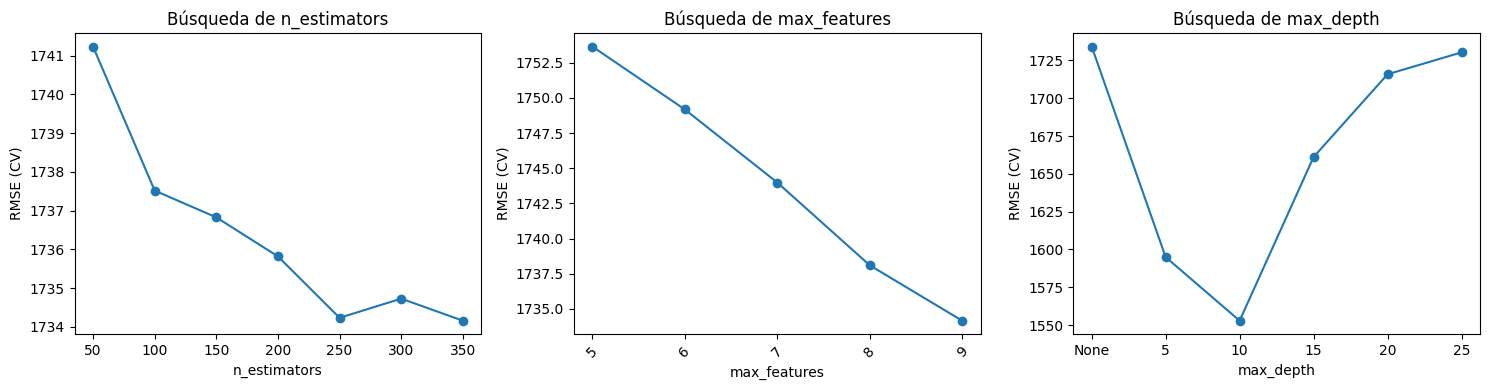


Mejores hiperparámetros encontrados:
n_estimators: 350
max_features: 9
max_depth: 10

Desempeño modelo ajustado:
RMSE train: 1,503,609
RMSE test:  2,499,983
MAE test:   1,161
R2 test:    0.837

Desempeño modelo base:
RMSE train: 431,028
RMSE test:  3,116,679
MAE test:   1,314
R2 test:    0.796

Top 5 importancias de variables:
      feature  importance
0        Year    0.772337
1     Mileage    0.188792
2  M_CamryXLE    0.016917
3   M_CamryLE    0.008552
4     M_Camry    0.007965


In [ ]:

# Celda 4 - RandomForestRegressor para predicción de precios con búsqueda manual de hiperparámetros
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preparación de variables para regresión basico
y_reg = data['Price']
X_reg = data.drop(['Price'], axis=1)

# División entrenamiento/prueba
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.33, random_state=42)

# Modelo base sin mejorar el arbol
rf_reg = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_reg.fit(Xr_train, yr_train)

# Evaluación base
pred_train = rf_reg.predict(Xr_train)
pred_test = rf_reg.predict(Xr_test)
rmse_train = mean_squared_error(yr_train, pred_train)
rmse_test = mean_squared_error(yr_test, pred_test)
mae_test = mean_absolute_error(yr_test, pred_test)
r2_test = r2_score(yr_test, pred_test)

# Búsqueda de hiperparámetros con validación cruzada
print('\n=== Búsqueda de hiperparámetros ===')

# Rango de hiperparámetros n_estimators
estimator_range = range(50, 351, 50)
feature_candidates = list(range(5, min(25, Xr_train.shape[1]) + 1))
depth_options = [None, 5, 10, 15, 20, 25]

# n_estimators
print('Buscando mejor n_estimators...')
estimator_scores = []
for n_estimators in estimator_range:
    mdl = RandomForestRegressor(n_estimators=n_estimators, random_state=42, n_jobs=-1)
    scores = cross_val_score(mdl, Xr_train, yr_train, cv=5, scoring='neg_root_mean_squared_error')
    estimator_scores.append((-scores).mean())

best_n_estimators = list(estimator_range)[int(np.argmin(estimator_scores))]

# max_features (usando mejor n_estimators)
print('Buscando mejor max_features...')
feature_scores = []
for mf in feature_candidates:
    mdl = RandomForestRegressor(n_estimators=best_n_estimators, max_features=mf, random_state=42, n_jobs=-1)
    scores = cross_val_score(mdl, Xr_train, yr_train, cv=5, scoring='neg_root_mean_squared_error')
    feature_scores.append((-scores).mean())

best_max_features = feature_candidates[int(np.argmin(feature_scores))]

# max_depth (usando mejores previos)
print('Buscando mejor max_depth...')
depth_scores = []
for md in depth_options:
    mdl = RandomForestRegressor(n_estimators=best_n_estimators, max_features=best_max_features, max_depth=md, random_state=42, n_jobs=-1)
    scores = cross_val_score(mdl, Xr_train, yr_train, cv=5, scoring='neg_root_mean_squared_error')
    depth_scores.append((-scores).mean())

best_max_depth = depth_options[int(np.argmin(depth_scores))]

# Gráficas de búsqueda
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(list(estimator_range), estimator_scores, marker='o')
plt.xlabel('n_estimators')
plt.ylabel('RMSE (CV)')
plt.title('Búsqueda de n_estimators')

plt.subplot(1, 3, 2)
plt.plot(list(range(len(feature_candidates))), feature_scores, marker='o')
plt.xticks(list(range(len(feature_candidates))), [str(x) for x in feature_candidates])
plt.xlabel('max_features')
plt.ylabel('RMSE (CV)')
plt.title('Búsqueda de max_features')

plt.subplot(1, 3, 3)
plt.plot([str(d) for d in depth_options], depth_scores, marker='o')
plt.xlabel('max_depth')
plt.ylabel('RMSE (CV)')
plt.title('Búsqueda de max_depth')
plt.tight_layout()
plt.show()

print(f'\nMejores hiperparámetros encontrados:')
print(f'n_estimators: {best_n_estimators}')
print(f'max_features: {best_max_features}')
print(f'max_depth: {best_max_depth}')

# Modelo final con mejores parámetros
best_reg = RandomForestRegressor(
    n_estimators=best_n_estimators,
    max_features=best_max_features,
    max_depth=best_max_depth,
    random_state=42,
    n_jobs=-1
)
best_reg.fit(Xr_train, yr_train)

# Evaluación del modelo final
best_pred_train = best_reg.predict(Xr_train)
best_pred_test = best_reg.predict(Xr_test)
rmse_train_best = mean_squared_error(yr_train, best_pred_train)
rmse_test_best = mean_squared_error(yr_test, best_pred_test)
mae_test_best = mean_absolute_error(yr_test, best_pred_test)
r2_test_best = r2_score(yr_test, best_pred_test)

print('\nDesempeño modelo ajustado:')
print(f'RMSE train: {rmse_train_best:,.0f}')
print(f'RMSE test:  {rmse_test_best:,.0f}')
print(f'MAE test:   {mae_test_best:,.0f}')
print(f'R2 test:    {r2_test_best:,.3f}')

print('\nDesempeño modelo base:')
print(f'RMSE train: {rmse_train:,.0f}')
print(f'RMSE test:  {rmse_test:,.0f}')
print(f'MAE test:   {mae_test:,.0f}')
print(f'R2 test:    {r2_test:,.3f}')


# Importancias de variables
fi = (
    pd.DataFrame({
        'feature': Xr_train.columns,
        'importance': best_reg.feature_importances_
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
print('\nTop 5 importancias de variables:')
print(fi.head(5))
